In [2]:
pip install pandas

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/11.5 MB 7.2 MB/s eta 0:00:02
   ----------- ---------------------------- 3.4/11.5 MB 8.5 MB/s eta 0:00:01
   ------------------ --------------------- 5.2/11.5 MB 8.7 MB/s eta 0:00:01
   --------------------- ------------------ 6.3/11.5 MB 7.7 MB/s eta 0:00:01
   ---------------------------- ----------- 8.1/11.5 MB 8.0 MB/s eta 0:00:01
   --------------------------------- ------ 9.7/11.5 MB 8.1 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.5 MB 8.0 MB/s eta 0:00:01
   ---------------------------------------- 11.5/11.5 MB 7.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.6/12.6 MB 7.4 MB/s eta 0:00:02
   --------- ------------------------------ 3.1/12.6 MB 7.3 MB/s eta 0:00:02
   -------


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/11.1 MB 8.8 MB/s eta 0:00:02
   ------------ --------------------------- 3.4/11.1 MB 8.9 MB/s eta 0:00:01
   ------------------ --------------------- 5.2/11.1 MB 9.0 MB/s eta 0:00:01
   -------------------------- ------------- 7.3/11.1 MB 9.2 MB/s eta 0:00:01
   --------------------------------- ------ 9.2/11.1 MB 9.1 MB/s eta 0:00:01
   ---------------------------------------  11.0/11.1 MB 9.1 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 8.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/41.0 MB ? eta -:--:--
   -- ------------------------------------- 2.4/41.0 MB 11.1 MB/s eta 0:00:04
   ---- ----------------------------------- 4.5/41.0 MB 10.7 MB/s eta 0:00:04
   ------ --------------------------------- 6.3/41.0 MB 10.2 MB/s eta 0:00:04
   ----


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.1 MB 8.4 MB/s eta 0:00:01
   ---------------- ----------------------- 3.4/8.1 MB 8.7 MB/s eta 0:00:01
   ----------------------- ---------------- 4.7/8.1 MB 8.2 MB/s eta 0:00:01
   -------------------------------- ------- 6.6/8.1 MB 8.1 MB/s eta 0:00:01
   ---------------------------------------  7.9/8.1 MB 7.9 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 7.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------- ----------- 1.6/2.2 MB 8.2 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 7.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------------------- -------------------- 1.3/2.7 MB 7.2 MB/s eta 0:00:01
   ----------------------------


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt


In [4]:

df = pd.read_csv('data.csv')  

# Drop the ID column and handle target
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})  # Malignant = 1, Benign = 0

# Split features and labels
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [6]:
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [7]:
y_pred = model.predict(X_test)


cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


print("\nClassification Report:\n", classification_report(y_test, y_pred))


y_pred_prob = model.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_pred_prob)
print("ROC AUC Score:", roc_auc)


Confusion Matrix:
 [[70  1]
 [ 2 41]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

ROC AUC Score: 0.99737962659679


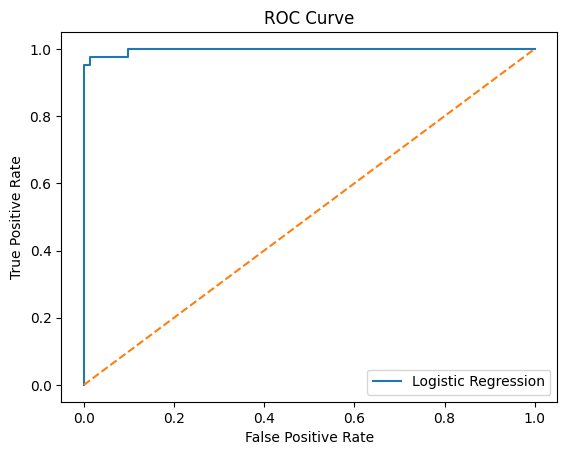

In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


In [10]:
custom_threshold = 0.3
y_pred_custom = (y_pred_prob >= custom_threshold).astype(int)
print("Confusion Matrix with 0.3 Threshold:\n", confusion_matrix(y_test, y_pred_custom))


Confusion Matrix with 0.3 Threshold:
 [[67  4]
 [ 1 42]]
